In [1]:
!uname -m

x86_64


In [1]:
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display
from IPython.display import Audio
import scipy.io.wavfile as wavfile
from scipy.signal import resample
from tqdm import tqdm

## Preprocess Data

In [52]:
#Convert categorical variables
df = pd.read_csv('data_full.csv')
df['Sex'] = df['Sex'].map({'Male': 0, 'Female': 1})
df['qxr_radiologist'] = df['qxr_radiologist'].map({'Normal': 0, 'Abnormal': 1})
df['Diabetes'] = df['Diabetes'].map({'Non Diabetic': 0, 'Diabetic': 1})
df[['Breathsounds','Breathdifficulty', 'Priortb', 'Hemoptysis', 'Weightloss', 'Smokedinlastweek', 'Fever', 'Nightsweats']] = df[['Breathsounds','Breathdifficulty', 'Priortb', 'Hemoptysis', 'Weightloss', 'Smokedinlastweek', 'Fever', 'Nightsweats']].apply(lambda x: x.map({'Yes': 1, 'No': 0}))
df['BMI'] = np.round(df['Weight'] / (.01 * df['Height']) ** 2, 2)
if (df['qxr_radiologist'].isnull().any()).any():
    df = df.dropna(subset=['qxr_radiologist'])
print("Class Balance: ", df['qxr_radiologist'].value_counts())
df

Class Balance:  qxr_radiologist
1.0    577
0.0    501
Name: count, dtype: int64


,Country,StudyID,Sex,Age,Height,Weight,Diabetes,HIVstatus,Durationofcough,Priortb,...,Temperature,Weightloss,Smokedinlastweek,Fever,Nightsweats,Breathsounds,Breathdifficulty,qxr_radiologist,audio_file,BMI
0,PH,R2D2011001,1,47,158.5,70.0,0,Negative,21,1.0,...,36.8,1,0,1,1,1,1,0.0,Merged/Rec_R2D2011001_23_12_06_08_12_15_XA_XI.WAV,27.86
1,PH,R2D2011002,1,41,150.0,48.5,0,Negative,0,0.0,...,36.8,0,0,0,0,0,0,1.0,Merged/Rec_R2D2011002_23_12_07_14_39_31_XA_M20...,21.56
2,PH,R2D2011003,0,50,157.0,54.5,1,Negative,30,1.0,...,36.7,1,1,0,1,1,0,1.0,Merged/Rec_R2D2011003_23_12_11_14_58_49_XA_M20...,22.11
3,PH,R2D2011007,0,48,179.0,79.5,0,Negative,240,0.0,...,37.0,1,1,1,1,1,1,1.0,Merged/Rec_R2D2011007_23_12_13_15_27_18_XA_M20...,24.81
4,PH,R2D2011009,1,63,151.5,62.9,0,Negative,30,0.0,...,36.7,1,0,1,1,1,1,0.0,Merged/Rec_R2D2011009_23_12_13_15_52_58_XA_M20...,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1088,IN,R2D205957,0,47,169.0,44.4,1,Negative,30,1.0,...,36.5,1,0,0,0,1,1,1.0,Merged/Rec_R2D205957_24_02_23_15_21_31_XA_moto...,15.55
1089,IN,R2D205958,0,64,168.0,68.5,0,Negative,30,0.0,...,36.6,0,0,1,1,1,1,1.0,Merged/Rec_R2D205958_24_02_23_16_14_03_XA_moto...,24.27
1090,IN,R2D205959,0,52,177.0,63.2,0,Negative,90,0.0,...,37.2,0,0,0,0,0,1,1.0,Merged/Rec_R2D205959_24_02_28_09_37_09_XA_moto...,20.17
1091,IN,R2D205960,1,32,154.0,48.4,0,Negative,180,0.0,...,37.0,1,0,1,0,0,0,1.0,Merged/Rec_R2D205960_24_02_26_13_35_00_XA_moto...,20.41


## Feature Extraction

In [4]:
SAMPLING_RATE = 16000 #or 22500
DURATION = 10

# Try out different sampling rates after
# Nyquist-Shannon Sampling Thm: The minimum sampling rate should be at least twice the highest frequency you want to capture in your signal to avoid aliasing

In [5]:
from scipy.signal import butter, filtfilt

def preprocess_audio(file_path, SAMPLING_RATE):
    """
    Load and preprocess audio files for analysis
    """
    audio, sr = librosa.load(file_path, sr=SAMPLING_RATE, mono=True) #Got rid of duration
    
    # Apply Bandpass filter (150-7500Hz)
    nyquist = 0.5 * sr
    low = 150 / nyquist
    high = 7500 / nyquist
    b, a = butter(5, [low, high], btype='band')
    audio_filtered = filtfilt(b, a, audio)
    
    # Segment the audio to isolate individual coughs (top_db < 25 considered silence)
    cough_segments = librosa.effects.split(audio_filtered, top_db=21)
    cough_audio = [audio_filtered[start:end] for start, end in cough_segments]
    
    return cough_audio, sr

In [ ]:
from scipy.stats import entropy, kurtosis, skew

def extract_audio_features(audio, sr=SAMPLING_RATE):
    """
    Extract multiple types of audio features for robust classification
    """
    features = {}
    
    # 1. MFCC Features (13 coefficients + derivatives)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13) #2D Array, like 40 MFCCs x N time frames
    
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
    
    # Statistical measures of MFCCs, extract fro each coefficient
    # 78 features
    features.update({
        'mfcc_mean': np.mean(mfccs, axis=1),
        'mfcc_std': np.std(mfccs, axis=1),
        'mfcc_delta_mean': np.mean(mfcc_delta, axis=1),
        'mfcc_delta_std': np.std(mfcc_delta, axis=1),
        'mfcc_delta2_mean': np.mean(mfcc_delta2, axis=1),
        'mfcc_delta2_std': np.std(mfcc_delta2, axis=1)
    })
    
    # 2. Spectral Features
    # 22 features
    spectral_centroids = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0]
    spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
    spectral_flatness = librosa.feature.spectral_flatness(y=audio)[0]
    spectral_flux = librosa.onset.onset_strength(y=audio, sr=sr)

    features.update({
        'spectral_centroid_std': np.std(spectral_centroids),
        'spectral_bandwidth_mean': np.mean(spectral_bandwidth),
        'spectral_bandwidth_std': np.std(spectral_bandwidth),
        'spectral_rolloff_std': np.std(spectral_rolloff),
        'spectral_contrast_mean': np.mean(spectral_contrast, axis=1), #7 default
        'spectral_contrast_std': np.std(spectral_contrast, axis=1),
        'spectral_flatness_mean': np.mean(spectral_flatness),
        'spectral_flatness_std': np.std(spectral_flatness),
        'spectral_flux_mean': np.mean(spectral_flux),
    })
    
    # 3. Rhythm and Temporal Features
    # 4 features
    zero_crossing_rate = librosa.feature.zero_crossing_rate(audio)[0]
    
    features.update({
        'zcr_mean': np.mean(zero_crossing_rate),
        'zcr_std': np.std(zero_crossing_rate),
    })
    
    # 4. Chroma and Tonal Features
    # 36 features

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(audio), sr=sr)
    
    features.update({
        'chroma_mean': np.mean(chroma, axis=1), #12 one per chroma bin
        'chroma_std': np.std(chroma, axis=1),
        'tonnetz_mean': np.mean(tonnetz, axis=1), #6 default
        'tonnetz_std': np.std(tonnetz, axis=1)
    })
    
    # 5. Energy and Power Features
    rms_energy = librosa.feature.rms(y=audio)[0]
    features.update({
        'rms_energy_std': np.std(rms_energy),
    })
    
    # 6. Mel-scale Features
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=40)
    mel_features = librosa.power_to_db(mel_spectrogram)
    
    features.update({
        'mel_mean': np.mean(mel_features, axis=1), #40 oen per mel band
        'mel_std': np.std(mel_features, axis=1)
    })
    
    #7. Time-domain features
    # 3 total
    features.update({
        'entropy': entropy(np.abs(audio)), 
        'skewness': skew(audio)
    })

    #8. STFT
    stft = np.abs(librosa.stft(audio, n_fft=1024, hop_length=256))
    features.update({
        'stft_skew': skew(stft.flatten()),
        'stft_kurtosis': kurtosis(stft.flatten())
    })
    
    return features

def flatten_features(feature_dict, sample_id=None):
    """
    Flatten nested feature dictionary into a single-row DataFrame
    """
    flat_dict = {}
    
    for key, value in feature_dict.items():
        if isinstance(value, np.ndarray):
            for i, v in enumerate(value):
                flat_dict[f"{key}_{i}"] = v
        else:
            flat_dict[key] = value
    
    df = pd.DataFrame([flat_dict])
    if sample_id is not None:
        df.index = [sample_id]
    
    return df

In [19]:
preprocessed_features = ['mfcc_delta_mean_11','mfcc_mean_5','mfcc_delta2_mean_6','mfcc_delta_mean_2','mfcc_delta_mean_4','spectral_contrast_mean_5','mfcc_mean_6','mfcc_delta_mean_5','mfcc_delta_mean_0','mfcc_delta2_mean_12','mfcc_delta2_mean_4','mfcc_delta2_mean_1','mfcc_mean_12','mfcc_delta_std_5','chroma_mean_3','mfcc_delta2_std_3','mel_mean_25','spectral_contrast_mean_6','mfcc_std_1','mel_mean_28','mel_mean_26','mel_mean_29','mfcc_delta2_std_5','mel_mean_24','mfcc_std_5','spectral_bandwidth_std','mfcc_std_4','mfcc_delta2_mean_3','mfcc_std_8','mel_mean_12','mfcc_delta_mean_6','chroma_mean_2','mel_mean_27','mel_mean_9','skewness','mel_mean_13','mel_mean_11','mel_mean_10','chroma_std_8','mel_std_5','mfcc_mean_2','mfcc_delta2_std_6','mel_mean_23','chroma_mean_4','mfcc_std_7','spectral_flatness_std','mel_mean_39','mel_std_17','mfcc_mean_4','mel_mean_8','mfcc_delta_mean_12','mfcc_mean_7','mfcc_mean_10','mel_mean_22','mel_mean_38','mel_std_18','mel_std_35','chroma_std_11','tonnetz_std_3','mel_std_32','mfcc_delta2_std_12','mel_mean_14','mel_std_3','mfcc_delta_std_10','mel_mean_21','mfcc_delta_std_1','mfcc_mean_0','mel_std_4','chroma_std_9','chroma_mean_5','mel_mean_19','mel_mean_20','mel_std_34','mel_mean_30','mfcc_delta_std_9','spectral_contrast_std_2','spectral_contrast_mean_4','stft_skew','entropy','mel_std_31','mel_mean_37','mfcc_std_9','tonnetz_std_0','mfcc_delta_std_4','mel_mean_15','mel_mean_17','mfcc_delta_mean_1','mfcc_delta2_std_2','chroma_std_7','tonnetz_mean_2','mel_std_30','spectral_centroid_std','mel_mean_16','mfcc_delta_std_3','mel_std_33','spectral_contrast_mean_0','mel_std_16','stft_kurtosis','mfcc_mean_8','mel_std_26','mel_mean_18','mfcc_delta_std_11','mel_std_6','mfcc_delta2_std_11','mel_mean_2','mfcc_delta2_mean_0','chroma_mean_8','mel_std_27','spectral_flux_mean','mel_std_38','chroma_mean_7','mfcc_std_11','spectral_flatness_mean','mel_std_36','mfcc_std_10','spectral_rolloff_std','mel_std_15','mel_mean_7','mfcc_std_3','mfcc_delta2_std_4','tonnetz_mean_1','chroma_mean_1','spectral_contrast_std_4','rms_energy_std','mel_mean_32','mel_mean_31','mfcc_delta_std_6','zcr_std','mfcc_delta_mean_10','mfcc_delta_std_8','spectral_contrast_std_0','mfcc_delta2_mean_2','mel_std_39','tonnetz_mean_0','mfcc_std_0','zcr_mean','mfcc_mean_11','mel_mean_1','tonnetz_mean_5','spectral_bandwidth_mean']

## Start Here Load Data

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Feature extraction
all_coughs_df = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    file_path = row['audio_file']
    label = row['qxr_radiologist']
    subject_id = idx

    # split into cough segments
    cough_segments, sr = preprocess_audio(file_path, SAMPLING_RATE)

    for i, segment in enumerate(cough_segments):
        if len(segment) < 4096: #can change lower to keep short coughs
            continue
        features_dict = extract_audio_features(segment, sr)
        feature_df = flatten_features(features_dict)
        feature_df['subject_id'] = subject_id
        feature_df['label'] = label
        all_coughs_df.append(feature_df)

cough_level_df = pd.concat(all_coughs_df, ignore_index=True)

count = 0
for feature in preprocessed_features:
    if feature not in cough_level_df.columns:
        count += 1
        # cough_level_df[feature] = 0
count

In [42]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score

features_df = pd.read_csv('features_full_df.csv')
features_df

,mfcc_delta_mean_11,mfcc_mean_5,mfcc_delta2_mean_6,mfcc_delta_mean_2,mfcc_delta_mean_4,spectral_contrast_mean_5,mfcc_mean_6,mfcc_delta_mean_5,mfcc_delta_mean_0,mfcc_delta2_mean_12,...,spectral_contrast_std_0,mfcc_delta2_mean_2,mel_std_39,tonnetz_mean_0,mfcc_std_0,zcr_mean,mfcc_mean_11,mel_mean_1,tonnetz_mean_5,spectral_bandwidth_mean
0,-0.044500,4.148535,0.003407,-0.131716,0.000129,17.661232,-7.685486,-0.027259,0.468163,-0.007841,...,4.430933,-0.016875,16.650774,0.016083,175.593260,0.152705,-5.093922,-23.134523,0.015400,2527.143411
1,0.004318,-3.617262,0.006113,-0.037394,0.034976,16.326452,-6.003392,-0.008175,0.232851,-0.005070,...,4.391366,-0.011908,9.285078,-0.007146,117.589990,0.064466,-9.003038,-16.015455,-0.009081,1878.568477
2,-0.003890,0.607513,-0.025165,-0.181940,-0.064857,16.537601,-8.157090,-0.101255,1.379632,-0.013639,...,5.002123,-0.046831,10.781588,0.024503,159.467800,0.131301,-7.583109,-20.269764,-0.002276,2429.538651
3,-0.013568,1.860461,-0.004052,-0.035300,-0.006493,16.409703,-11.130350,-0.013933,0.696865,0.034271,...,5.499055,-0.006698,15.511534,-0.038837,173.571200,0.147670,-4.716848,-10.651650,-0.003900,2406.989424
4,-0.030722,-0.242974,0.002193,-0.154911,-0.051947,18.074724,-17.794977,0.023629,0.718089,0.003855,...,5.400711,-0.034554,14.009627,-0.029842,192.239410,0.128724,-11.648885,-15.910852,-0.010485,2423.002225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,0.011721,9.461732,-0.023776,0.074279,0.019507,15.219089,-6.598399,0.030894,0.646037,-0.004768,...,4.677196,-0.030452,10.435080,0.002978,109.011635,0.163809,2.454574,-3.075807,-0.023990,3215.030951
1074,0.002768,-6.175189,-0.005639,0.065861,0.050199,15.516385,1.146824,-0.018414,0.740983,0.003100,...,4.225026,-0.033018,11.132030,0.039370,102.985886,0.184545,2.453410,-2.651073,0.006598,3496.262053
1075,0.003767,3.195126,-0.003704,-0.047682,0.050463,17.305665,-0.767884,-0.038134,1.511535,0.002530,...,5.387214,-0.033003,13.736762,-0.018249,112.733530,0.201511,9.003880,-3.772605,-0.000100,3195.770173
1076,0.004764,-0.746802,-0.011025,0.098848,0.038855,15.173344,3.669843,0.004918,0.817897,-0.002817,...,4.486603,-0.028374,13.575652,-0.021850,91.339720,0.217177,2.805520,-1.953345,0.000951,3455.760149


### Recording features 

In [47]:
from tqdm import tqdm

def extract_recording_level_features(file_path):
    audio, _ = librosa.load(file_path, sr=SAMPLING_RATE, mono=True)
    
    # Same bandpass filter as your preprocess_audio
    nyquist = 0.5 * SAMPLING_RATE
    b, a = butter(5, [150/nyquist, 7500/nyquist], btype='band')
    audio_filtered = filtfilt(b, a, audio)
    
    intervals = librosa.effects.split(audio_filtered, top_db=21)
    
    durations = [(e - s) / SAMPLING_RATE for s, e in intervals]
    gaps      = [(intervals[i+1][0] - intervals[i][1]) / SAMPLING_RATE
                 for i in range(len(intervals) - 1)] if len(intervals) > 1 else [0]
    
    cough_samples = np.concatenate([audio_filtered[s:e] for s, e in intervals]) if len(intervals) > 0 else np.array([0.0])
    total_energy  = np.sum(audio_filtered**2) + 1e-10
    cough_energy  = np.sum(cough_samples**2)

    return {
        'cough_count':              len(intervals),
        'cough_rate':               len(intervals) / (len(audio) / SAMPLING_RATE),
        'mean_cough_duration':      np.mean(durations),
        'std_cough_duration':       np.std(durations),
        'total_cough_duration':     np.sum(durations),
        'mean_intercough_interval': np.mean(gaps),
        'std_intercough_interval':  np.std(gaps),
        'cough_regularity':         np.std(gaps) / (np.mean(gaps) + 1e-6),
        'cough_energy_ratio':       cough_energy / total_energy,
        'recording_duration':       len(audio) / SAMPLING_RATE,
    }

# Extract once per subject — uses df which already has audio_file paths
recording_features = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    feats = extract_recording_level_features(row['audio_file'])
    feats['subject_id'] = idx  # idx will be gapped values matching cough_level_df
    recording_features.append(feats)

recording_features_df = pd.DataFrame(recording_features)
print(f"subject_id range: {recording_features_df['subject_id'].min()} to {recording_features_df['subject_id'].max()}")
# Should now print: subject_id range: 0 to 1092

recording_features_df.to_csv('recording_level_features_full.csv', index=False)

100%|██████████| 1078/1078 [00:15<00:00, 70.74it/s]

subject_id range: 0 to 1092


In [5]:
# recording_features_df.to_csv('recording_level_features_full.csv')
recording_features_df = pd.read_csv('recording_level_features_full.csv', index_col=0)

## 1. Baseline: acoustic features only (no demographics)


In [43]:
pd.read_csv('recording_level_features_full.csv', index_col=0)

,cough_count,cough_rate,mean_cough_duration,std_cough_duration,total_cough_duration,mean_intercough_interval,std_intercough_interval,cough_regularity,cough_energy_ratio,recording_duration,subject_id
0,6,0.602436,0.400000,0.084159,2.400000,1.088000,0.600714,0.552127,0.997788,9.959563,0
1,5,0.504054,0.364800,0.104381,1.824000,1.640000,0.207846,0.126735,0.997974,9.919562,1
2,5,0.504054,0.473513,0.217564,2.367563,1.488000,0.653263,0.439020,0.998244,9.919562,2
3,10,1.008109,0.444756,0.095366,4.447563,0.494222,0.469360,0.949693,0.997467,9.919562,3
4,6,0.602436,0.613333,0.311030,3.680000,1.017600,1.104700,1.085593,0.998489,9.959563,4
...,...,...,...,...,...,...,...,...,...,...,...
1073,8,0.803611,0.400000,0.090510,3.200000,0.740571,0.689180,0.930604,0.987805,9.955063,1088
1074,7,0.703160,0.461714,0.321758,3.232000,0.576000,0.587732,1.020367,0.981828,9.955063,1089
1075,7,0.706041,0.794634,0.302457,5.562437,0.602667,0.286465,0.475328,0.996416,9.914438,1090
1076,10,1.008630,0.400000,0.150944,4.000000,0.440889,0.368819,0.836534,0.972902,9.914438,1091


In [90]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

# df should already be the cleaned 1078-row dataframe from earlier:
# - qxr_radiologist dropped if missing
# - index NOT reset after that drop
# - this index is your canonical subject_id space

# Load acoustic features only
features_df = pd.read_csv('features_full_df.csv').reset_index(drop=True)

# Create/keep subject_id from the preserved df index
if 'subject_id' not in df.columns:
    df = df.copy()
    df['subject_id'] = df.index.astype(int)

# Attach subject_id to features_df using the same row order
assert len(features_df) == len(df), (
    f"Row mismatch: features_df={len(features_df)} vs df={len(df)}"
)

features_df = features_df.copy()
features_df['subject_id'] = df['subject_id'].values

# --- Train/val ids from segmented split (gappy IDs) ---
train_subjects = pd.read_csv('train_subjects_segment.csv', header=None)[0].astype(int).tolist()
val_subjects   = pd.read_csv('val_subjects_segment.csv', header=None)[0].astype(int).tolist()

print(f"✅ Shapes: Features={features_df.shape}, Labels={df.shape}")

# --- Build acoustic_df keyed by subject_id ---
acoustic_features_cols = [c for c in features_df.columns if c != 'subject_id']

acoustic_df = features_df.merge(
    df[['subject_id', 'qxr_radiologist']],
    on='subject_id',
    how='inner'
).rename(columns={'qxr_radiologist': 'label'})

print("✅ acoustic_df rows:", len(acoustic_df), "unique subjects:", acoustic_df['subject_id'].nunique())

X_acoustic = acoustic_df[acoustic_features_cols]
y_acoustic = acoustic_df['label'].astype(int)
subjects   = acoustic_df['subject_id'].astype(int)

train_mask = subjects.isin(train_subjects)
val_mask   = subjects.isin(val_subjects)

print(f"✅ Split - Train: {train_mask.sum()}, Val: {val_mask.sum()}")
print("✅ Train overlap:", len(set(train_subjects).intersection(set(subjects))))
print("✅ Val overlap:", len(set(val_subjects).intersection(set(subjects))))

X_train_ac = X_acoustic[train_mask].values
y_train_ac = y_acoustic[train_mask].values
X_val_ac   = X_acoustic[val_mask].values
y_val_ac   = y_acoustic[val_mask].values

val_subjects_df = acoustic_df[val_mask][['subject_id', 'label']].drop_duplicates().set_index('subject_id')

scaler_ac = RobustScaler()
X_train_ac_scaled = scaler_ac.fit_transform(X_train_ac)
X_val_ac_scaled   = scaler_ac.transform(X_val_ac)

models = {
    "RF": RandomForestClassifier(n_estimators=250, max_depth=10, random_state=42),
    "SVM": SVC(C=1.0, kernel='rbf', probability=True, random_state=42),
    "LR": LogisticRegression(max_iter=1000, random_state=42)
}

baseline_acoustic_results = {}
print("\n🎯 Acoustic Baseline Results:")
for name, model in models.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train_ac_scaled, y_train_ac)
    probs = model.predict_proba(X_val_ac_scaled)[:, 1]

    auc_results_df = val_subjects_df.copy()
    auc_results_df["probability"] = probs

    auc_score = roc_auc_score(auc_results_df["label"], auc_results_df["probability"])
    baseline_acoustic_results[name] = (
        auc_results_df["label"].values,
        (auc_results_df["probability"] >= 0.5).astype(int).values,
        auc_results_df["probability"].values
    )
    print(f"{auc_score:.4f}")

✅ Shapes: Features=(1078, 141), Labels=(1078, 23)
✅ acoustic_df rows: 1078 unique subjects: 1078
✅ Split - Train: 846, Val: 212
✅ Train overlap: 846
✅ Val overlap: 212

🎯 Acoustic Baseline Results:
Training RF... 0.6280
Training SVM... 0.6371
Training LR... 0.6555


## 2. Add Recording Features

In [91]:
# =====================================================================
# CHUNK 2: ACOUSTIC + RECORDING FEATURES (KEYED BY subject_id)
# =====================================================================

recording_cols = [
    'cough_count', 'cough_rate', 'mean_cough_duration', 'std_cough_duration',
    'total_cough_duration', 'mean_intercough_interval', 'std_intercough_interval',
    'cough_regularity', 'cough_energy_ratio', 'recording_duration'
]

print(f"✅ Adding {len(recording_cols)} recording features from recording_features_df...")

# Keep only the columns we need
rec_df = recording_features_df[['subject_id'] + recording_cols].copy()
rec_df['subject_id'] = rec_df['subject_id'].astype(int)

# Sanity checks on the recording table
assert rec_df['subject_id'].is_unique, "Duplicate subject_id values in recording_features_df"

# Merge recording features onto acoustic_df using subject_id
acoustic_plus_rec_df = acoustic_df.merge(
    rec_df,
    on='subject_id',
    how='left',
    validate='one_to_one'
)

# Check for any missing recording features after merge
missing_rec = acoustic_plus_rec_df[recording_cols].isna().any(axis=1).sum()
assert missing_rec == 0, f"{missing_rec} subjects are missing recording features after merge"

# Build X matrix (exclude label + subject_id)
X_acoustic_recording = acoustic_plus_rec_df.drop(columns=['subject_id', 'label'])

# Recompute masks from THIS dataframe
subjects_rec = acoustic_plus_rec_df['subject_id'].astype(int)
train_mask_rec = subjects_rec.isin(train_subjects)
val_mask_rec   = subjects_rec.isin(val_subjects)

X_train_rec = X_acoustic_recording[train_mask_rec].values
X_val_rec   = X_acoustic_recording[val_mask_rec].values
y_train_rec = acoustic_plus_rec_df.loc[train_mask_rec, 'label'].astype(int).values
y_val_rec   = acoustic_plus_rec_df.loc[val_mask_rec, 'label'].astype(int).values

val_subjects_df_rec = acoustic_plus_rec_df[val_mask_rec][['subject_id', 'label']].drop_duplicates().set_index('subject_id')

# Scale
scaler_rec = RobustScaler()
X_train_rec_scaled = scaler_rec.fit_transform(X_train_rec)
X_val_rec_scaled   = scaler_rec.transform(X_val_rec)

print(f"✅ Recording shapes: X={X_train_rec_scaled.shape}, y={y_train_rec.shape}")

# Train models
baseline_recording_results = {}
print("\n🎯 Acoustic + Recording Results:")
for name, model in models.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train_rec_scaled, y_train_rec)
    probs = model.predict_proba(X_val_rec_scaled)[:, 1]

    auc_results_df = val_subjects_df_rec.copy()
    auc_results_df['probability'] = probs

    auc_score = roc_auc_score(auc_results_df['label'], auc_results_df['probability'])
    baseline_recording_results[name] = (
        auc_results_df['label'].values,
        (auc_results_df['probability'] >= 0.5).astype(int).values,
        auc_results_df['probability'].values
    )
    print(f"{auc_score:.4f}")

# Improvement comparison
print("\n📈 IMPROVEMENT ANALYSIS:")
for name in models:
    acoustic_auc  = roc_auc_score(baseline_acoustic_results[name][0], baseline_acoustic_results[name][2])
    recording_auc = roc_auc_score(baseline_recording_results[name][0], baseline_recording_results[name][2])
    delta = recording_auc - acoustic_auc
    status = "✅ IMPROVED" if delta > 0 else "➡️ SAME/WORSE"
    print(f"{name}: {recording_auc:.4f} vs {acoustic_auc:.4f} ({delta:+.4f}) {status}")

✅ Adding 10 recording features from recording_features_df...
✅ Recording shapes: X=(846, 150), y=(846,)

🎯 Acoustic + Recording Results:
Training RF... 0.6229
Training SVM... 0.6390
Training LR... 0.6593

📈 IMPROVEMENT ANALYSIS:
RF: 0.6229 vs 0.6280 (-0.0051) ➡️ SAME/WORSE
SVM: 0.6390 vs 0.6371 (+0.0019) ✅ IMPROVED
LR: 0.6593 vs 0.6555 (+0.0038) ✅ IMPROVED


## 3. Acoustic + Recording + Demographics

In [92]:
# =====================================================================
# CHUNK 4: ACOUSTIC + RECORDING + DEMOGRAPHICS (KEYED BY subject_id)
# =====================================================================

demo_cols = [
    'Age', 'Sex', 'Diabetes', 'BMI', 'Breathsounds', 'Breathdifficulty',
    'Durationofcough', 'Priortb', 'Hemoptysis', 'Heartrate',
    'Temperature', 'Weightloss', 'Smokedinlastweek', 'Fever', 'Nightsweats'
]

print(f"Adding {len(demo_cols)} demographic features...")

# Build a subject_id -> demographics table from the cleaned df
demo_df = df[['subject_id'] + demo_cols].copy()
demo_df['subject_id'] = demo_df['subject_id'].astype(int)
assert demo_df['subject_id'].is_unique, "Duplicate subject_id values in demo_df"

# Merge demographics onto the already-built acoustic+recording dataframe
full_df = acoustic_plus_rec_df.merge(
    demo_df,
    on='subject_id',
    how='left',
    validate='one_to_one'
)

print(f"After demographic merge (before drop): {full_df.shape}")
assert full_df['subject_id'].is_unique, "Expected one row per subject after merge."

# Identify and drop missing demographic rows
missing_rows = full_df[full_df[demo_cols].isna().any(axis=1)]
print(f"Dropping {len(missing_rows)} subjects with missing demographics")

full_df = full_df.dropna(subset=demo_cols).copy()

print(f"After dropping missing demographics: {full_df.shape}")
assert full_df[demo_cols].isna().sum().sum() == 0, "Still missing demographic values after drop"

# Build X and y
X_full_df = full_df.drop(columns=['subject_id', 'label'])
y_full = full_df['label'].astype(int)
subjects_full = full_df['subject_id'].astype(int)

# Recompute masks in THIS dataframe
train_mask_full = subjects_full.isin(train_subjects)
val_mask_full   = subjects_full.isin(val_subjects)

X_train_full = X_full_df[train_mask_full].values
X_val_full   = X_full_df[val_mask_full].values
y_train_full = y_full[train_mask_full].values
y_val_full   = y_full[val_mask_full].values

val_subjects_df_full = full_df[val_mask_full][['subject_id', 'label']].drop_duplicates().set_index('subject_id')

print(f"✅ Full training shapes: X={X_train_full.shape}, y={y_train_full.shape}")
print(f"✅ Full validation shapes: X={X_val_full.shape}, y={y_val_full.shape}")

# Scale
scaler_full = RobustScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_val_full_scaled   = scaler_full.transform(X_val_full)

# Train models
baseline_full_results = {}
print("\nFull Feature Set Results (Acoustic + Recording + Demographics):")
for name, model in models.items():
    print(f"Training {name}... ", end="")
    model.fit(X_train_full_scaled, y_train_full)
    probs = model.predict_proba(X_val_full_scaled)[:, 1]

    auc_results_df = val_subjects_df_full.copy()
    auc_results_df['probability'] = probs

    auc_score = roc_auc_score(auc_results_df['label'], auc_results_df['probability'])
    baseline_full_results[name] = (
        auc_results_df['label'].values,
        (auc_results_df['probability'] >= 0.5).astype(int).values,
        auc_results_df['probability'].values
    )
    print(f"{auc_score:.4f}")

# Comparison table
print("\n" + "="*70)
print("FINAL COMPARISON: All Feature Sets")
print("="*70)

comparison_data = []
for name in models:
    comparison_data.append({
        'Model': name,
        'Acoustic': f"{roc_auc_score(baseline_acoustic_results[name][0], baseline_acoustic_results[name][2]):.4f}",
        'Acoustic+Recording': f"{roc_auc_score(baseline_recording_results[name][0], baseline_recording_results[name][2]):.4f}",
        'Full (w/ Demographics)': f"{roc_auc_score(baseline_full_results[name][0], baseline_full_results[name][2]):.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4).to_string(index=False))

print("\nCHUNK 4 COMPLETE - Full pipeline ready for visualizations!")

Adding 15 demographic features...
After demographic merge (before drop): (1078, 167)
Dropping 2 subjects with missing demographics
After dropping missing demographics: (1076, 167)
✅ Full training shapes: X=(844, 165), y=(844,)
✅ Full validation shapes: X=(212, 165), y=(212,)

Full Feature Set Results (Acoustic + Recording + Demographics):
Training RF... 0.7611
Training SVM... 0.7582
Training LR... 0.8030

FINAL COMPARISON: All Feature Sets
Model Acoustic Acoustic+Recording Full (w/ Demographics)
   RF   0.6280             0.6229                 0.7611
  SVM   0.6371             0.6390                 0.7582
   LR   0.6555             0.6593                 0.8030

CHUNK 4 COMPLETE - Full pipeline ready for visualizations!


## Training

In [ ]:
# from pytorch_tabnet.tab_model import TabNetClassifier
# import torch

# # --- 1. Define the TabNetClassifier ---
# # We can set a seed for reproducibility, similar to your random_state=42
# clf = TabNetClassifier(
#     optimizer_fn=torch.optim.Adam,
#     optimizer_params=dict(lr=1e-2),
#     scheduler_params={"step_size":5, "gamma":0.9},
#     scheduler_fn=torch.optim.lr_scheduler.StepLR,
#     mask_type='sparsemax', # 'sparsemax' or 'entmax'
#     seed=42,
#     verbose=1 # Set to 1 to see training progress
# )

# # --- 2. Train the model ---
# # Pass the 1D y_train and y_val directly
# print("Starting TabNet training...")
# clf.fit(
#     X_train=X_train_scaled,
#     y_train=y_train,                   # <-- Use 1D y_train
#     eval_set=[(X_val_scaled, y_val)],  # <-- Use 1D y_val
#     eval_name=['validation'],
#     eval_metric=['auc', 'accuracy'], 
#     max_epochs=50,
#     patience=10,
#     batch_size=16,
#     drop_last=False
# )

# # --- 3. Predict and Evaluate ---
# y_prob_tabnet = clf.predict_proba(X_val_scaled)[:, 1]
# y_pred_tabnet = clf.predict(X_val_scaled)

# print("\nTabNet Performance:")
# print(classification_report(y_val, y_pred_tabnet))
# print(f"AUC: {roc_auc_score(y_val, y_prob_tabnet):.4f}")

## Visualizations

🏆 FULL COUGH PIPELINE - COMPLETE VISUALIZATION SUITE

📊 1️⃣ ACOUSTIC FEATURES ONLY


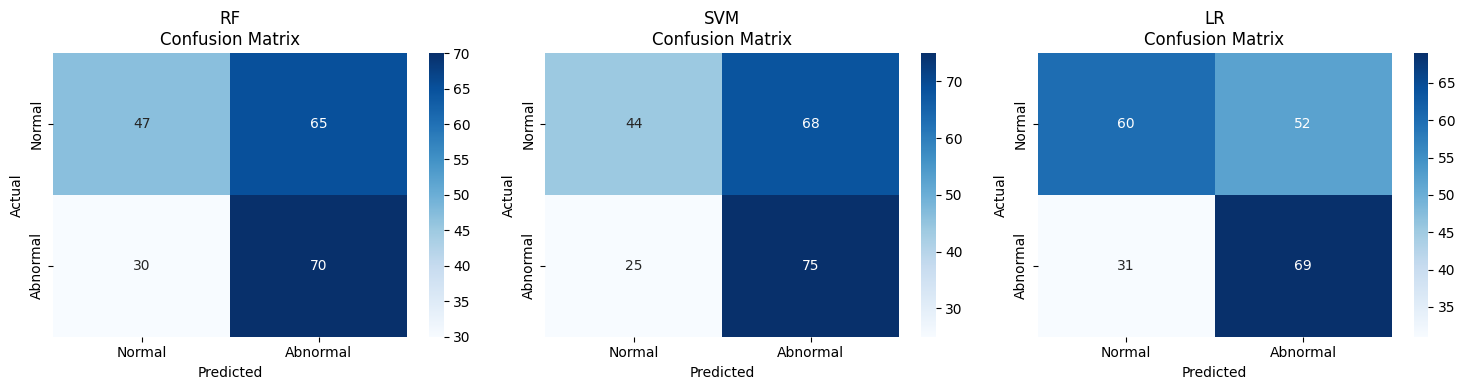

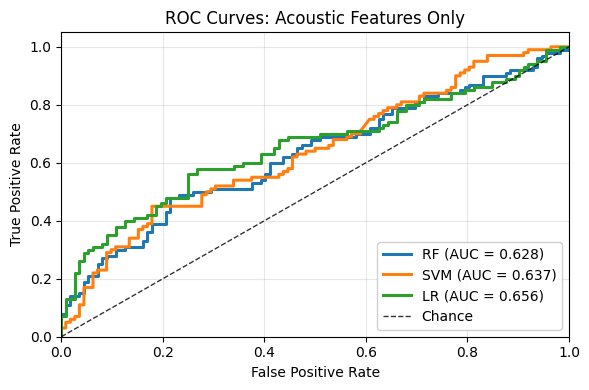

✓ Saved ROC arrays to: roc_full_acoustic_only.npz

--- Model Performance Metrics (Acoustic Only) ---


,Sensitivity (Recall),Specificity,PPV (Precision),NPV,Accuracy,AUC
Model,,,,,,
RF,0.700,0.420,0.519,0.610,0.552,0.628
SVM,0.750,0.393,0.524,0.638,0.561,0.637
LR,0.690,0.536,0.570,0.659,0.608,0.656




📊 2️⃣ ACOUSTIC + RECORDING FEATURES


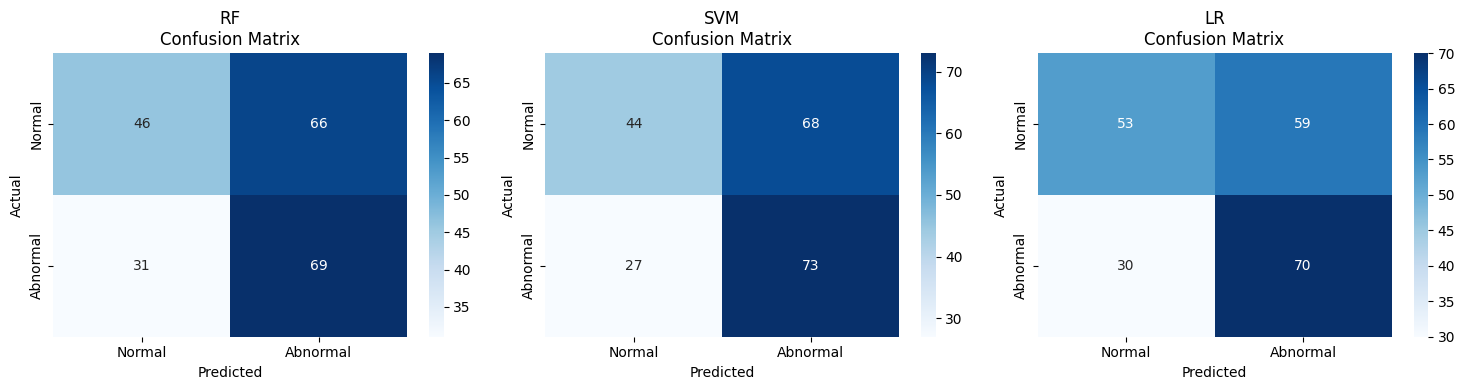

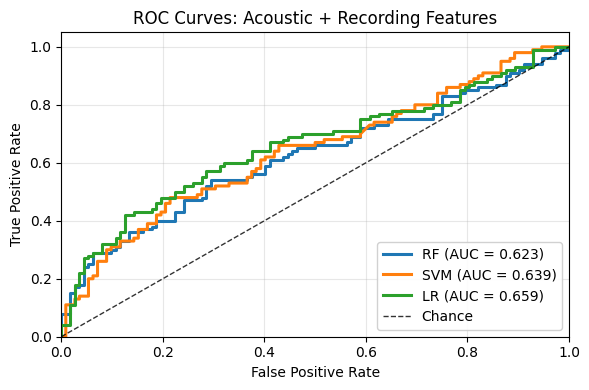

✓ Saved ROC arrays to: roc_full_acoustic_recording.npz

--- Model Performance Metrics (Acoustic + Recording) ---


,Sensitivity (Recall),Specificity,PPV (Precision),NPV,Accuracy,AUC
Model,,,,,,
RF,0.690,0.411,0.511,0.597,0.542,0.623
SVM,0.730,0.393,0.518,0.620,0.552,0.639
LR,0.700,0.473,0.543,0.639,0.580,0.659




📊 3️⃣ FULL PIPELINE


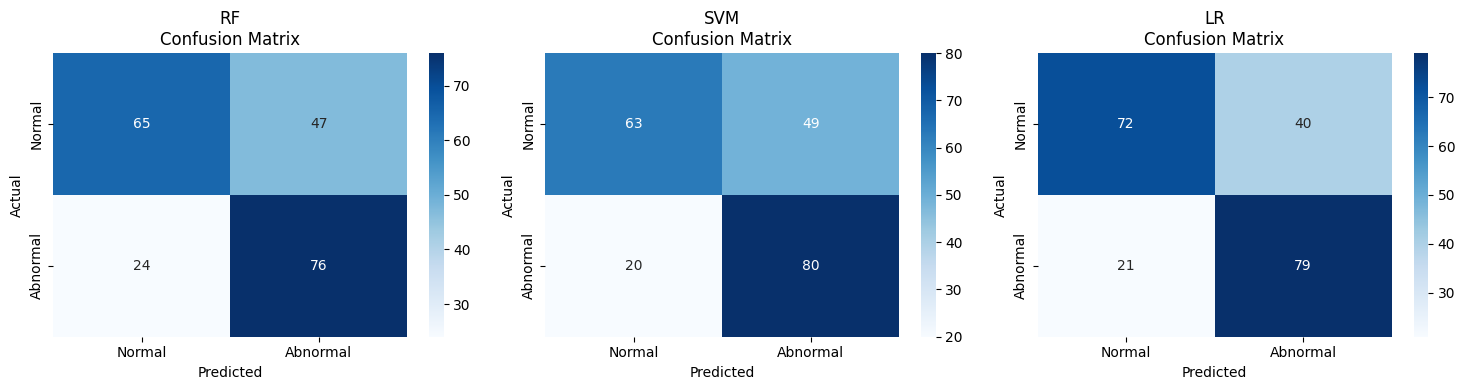

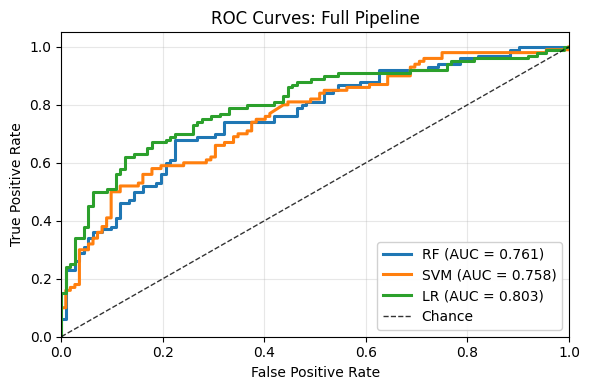

✓ Saved ROC arrays to: roc_full_pipeline.npz

--- Model Performance Metrics (Full Pipeline) ---


,Sensitivity (Recall),Specificity,PPV (Precision),NPV,Accuracy,AUC
Model,,,,,,
RF,0.760,0.580,0.618,0.730,0.665,0.761
SVM,0.800,0.562,0.620,0.759,0.675,0.758
LR,0.790,0.643,0.664,0.774,0.712,0.803




🏆 FINAL COMPARISON: All Feature Sets x All Models
Model Acoustic Acoustic+Recording Full (w/ Demographics)
   RF   0.6280             0.6229                 0.7611
  SVM   0.6371             0.6390                 0.7582
   LR   0.6555             0.6593                 0.8030

✅ FULL VISUALIZATION SUITE COMPLETE!


In [93]:
## Visualizations - FULLY COMPATIBLE WITH YOUR FULL COUGH PIPELINE (ALL BASELINES)
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

def plot_confusion_matrices(results_dict, figsize=(8, 6)):
    """Plot confusion matrices for all models"""
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, (y_true, y_pred, y_prob)) in enumerate(results_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Normal', 'Abnormal'],
                   yticklabels=['Normal', 'Abnormal'],
                   ax=axes[idx])
        
        axes[idx].set_title(f'{model_name}\nConfusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curves(results_dict, figsize=(6, 4), title="ROC Curves Comparison",
                    save_npz_path=None):
    """
    results_dict: {model_name: (y_true, y_pred, y_prob)}
    If save_npz_path is provided, saves:
      - {model}__y_true, {model}__y_prob, {model}__fpr, {model}__tpr, {model}__thr, {model}__auc
    """
    plt.figure(figsize=figsize)

    pack = {}
    for model_name, (y_true, y_pred, y_prob) in results_dict.items():
        y_true = np.asarray(y_true)
        y_prob = np.asarray(y_prob)

        fpr, tpr, thr = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        # Plot
        plt.plot(fpr, tpr, linewidth=2.2, label=f'{model_name} (AUC = {roc_auc:.3f})')

        # Save arrays
        safe = model_name.replace(" ", "_").replace("/", "_")
        pack[f"{safe}__y_true"] = y_true
        pack[f"{safe}__y_prob"] = y_prob
        pack[f"{safe}__fpr"] = fpr
        pack[f"{safe}__tpr"] = tpr
        pack[f"{safe}__thr"] = thr
        pack[f"{safe}__auc"] = np.array([roc_auc])

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.8, label='Chance')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right", framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if save_npz_path is not None:
        np.savez(save_npz_path, **pack)
        print(f"✓ Saved ROC arrays to: {save_npz_path}")

    return pack

def calculate_metrics(y_true, y_pred, y_prob):
    """Calculate sensitivity, specificity, and other metrics"""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'PPV (Precision)': ppv,
        'NPV': npv,
        'Accuracy': accuracy,
        'AUC': roc_auc
    }

def create_metrics_table(results_dict):
    """EXACT REPLICA of segmented version"""
    metrics_data = []
    
    for model_name, (y_true, y_pred, y_prob) in results_dict.items():
        metrics = calculate_metrics(y_true, y_pred, y_prob)
        metrics['Model'] = model_name
        metrics_data.append(metrics)
    
    metrics_df = pd.DataFrame(metrics_data).set_index('Model')
    
    styled_df = metrics_df.style.format({
        'Sensitivity (Recall)': '{:.3f}',
        'Specificity': '{:.3f}',
        'PPV (Precision)': '{:.3f}',
        'NPV': '{:.3f}',
        'Accuracy': '{:.3f}',
        'AUC': '{:.3f}'
    }).background_gradient(cmap='RdYlGn', subset=['AUC', 'Accuracy'])
    
    return metrics_df, styled_df

# =====================================================================
# 🎯 COMPLETE VISUALIZATION SUITE - ALL THREE BASELINES
# =====================================================================

print("🏆 FULL COUGH PIPELINE - COMPLETE VISUALIZATION SUITE")
print("="*70)

# =====================================================================
# 1. ACOUSTIC FEATURES ONLY
# =====================================================================
print("\n📊 1️⃣ ACOUSTIC FEATURES ONLY")
plot_confusion_matrices(baseline_acoustic_results, figsize=(15, 4))
plot_roc_curves(baseline_acoustic_results, title='ROC Curves: Acoustic Features Only', save_npz_path="roc_full_acoustic_only.npz")
print("\n--- Model Performance Metrics (Acoustic Only) ---")
metrics_acoustic_df, styled_acoustic = create_metrics_table(baseline_acoustic_results)
display(styled_acoustic)
print()

# =====================================================================
# 2. ACOUSTIC + RECORDING FEATURES
# =====================================================================
print("\n📊 2️⃣ ACOUSTIC + RECORDING FEATURES")
plot_confusion_matrices(baseline_recording_results, figsize=(15, 4))
plot_roc_curves(baseline_recording_results, title='ROC Curves: Acoustic + Recording Features', save_npz_path="roc_full_acoustic_recording.npz")
print("\n--- Model Performance Metrics (Acoustic + Recording) ---")
metrics_recording_df, styled_recording = create_metrics_table(baseline_recording_results)
display(styled_recording)
print()

# =====================================================================
# 3. FULL PIPELINE (Acoustic + Recording + Demographics)
# =====================================================================
print("\n📊 3️⃣ FULL PIPELINE")
plot_confusion_matrices(baseline_full_results, figsize=(15, 4))
plot_roc_curves(baseline_full_results, title='ROC Curves: Full Pipeline', save_npz_path="roc_full_pipeline.npz")
print("\n--- Model Performance Metrics (Full Pipeline) ---")
metrics_full_df, styled_full = create_metrics_table(baseline_full_results)
display(styled_full)
print()

# =====================================================================
# 4. FINAL COMPARISON TABLE - ALL FEATURE SETS (BUG FIXED)
# =====================================================================
print("\n" + "="*80)
print("🏆 FINAL COMPARISON: All Feature Sets x All Models")
print("="*80)
comparison_data = []
for name in models.keys():
    comparison_data.append({
        'Model': name,
        'Acoustic': f"{roc_auc_score(baseline_acoustic_results[name][0], baseline_acoustic_results[name][2]):.4f}",
        'Acoustic+Recording': f"{roc_auc_score(baseline_recording_results[name][0], baseline_recording_results[name][2]):.4f}",  # ✅ FIXED
        'Full (w/ Demographics)': f"{roc_auc_score(baseline_full_results[name][0], baseline_full_results[name][2]):.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4).to_string(index=False))
print("\n✅ FULL VISUALIZATION SUITE COMPLETE!")


In [94]:
def style_breakdown_table(breakdown_df, min_n_for_fade=10):
    """
    - Metrics (AUC/Sens/Spec/Acc) always mapped to [0,1] so 1.0 is darkest green
    - Low-N rows are de-emphasized ONLY in non-metric columns
    - Compatible with older pandas (no set_na_rep)
    """
    import pandas as pd

    df_show = breakdown_df.copy()

    metric_cols = [c for c in ['AUC', 'Sensitivity', 'Specificity', 'Accuracy'] if c in df_show.columns]
    non_metric_cols = [c for c in df_show.columns if c not in metric_cols]

    # Use na_rep if available; otherwise, just format without it
    try:
        styler = df_show.style.format({
            'N': '{:,.0f}',
            'Sensitivity': '{:.3f}',
            'Specificity': '{:.3f}',
            'Accuracy': '{:.3f}',
            'AUC': '{:.3f}'
        }, na_rep="—")
    except TypeError:
        styler = df_show.style.format({
            'N': '{:,.0f}',
            'Sensitivity': '{:.3f}',
            'Specificity': '{:.3f}',
            'Accuracy': '{:.3f}',
            'AUC': '{:.3f}'
        })

    # Fixed normalization so 1.0 is always darkest green
    if metric_cols:
        styler = styler.background_gradient(
            cmap='RdYlGn',
            subset=metric_cols,
            vmin=0, vmax=1
        )

    # Fade only non-metric columns for low-N rows (keeps metric colors strong)
    def fade_small_n(row):
        styles = [''] * len(row)
        if 'N' in row.index and pd.notna(row['N']) and row['N'] < min_n_for_fade:
            for i, col in enumerate(row.index):
                if col in non_metric_cols:
                    styles[i] = 'opacity: 0.55'
        return styles

    styler = styler.apply(fade_small_n, axis=1)

    return styler

def analyze_performance_by_group_full(df_meta, subject_results_df, analysis_cols, min_n=2):
    """
    df_meta: must contain 'subject_id' + demographics
    subject_results_df: must contain 'subject_id','y_true','y_pred','y_prob'
    """

    print(f"\n--- In-depth Performance Analysis ---")

    # Merge predictions with subject metadata by subject_id
    merged = df_meta.merge(
        subject_results_df[['subject_id', 'y_true', 'y_pred', 'y_prob']],
        on='subject_id',
        how='inner'
    )

    if merged.empty:
        raise ValueError("Merged df is empty. subject_id mismatch between df_meta and subject_results_df.")

    rows = []

    # Overall performance (safe confusion matrix)
    cm = confusion_matrix(merged['y_true'], merged['y_pred'], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    overall_metrics = {
        'Group': 'Overall',
        'Level': 'All',
        'N': len(merged),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn) > 0 else np.nan,
        'AUC': roc_auc_score(merged['y_true'], merged['y_prob']) if merged['y_true'].nunique() == 2 else np.nan
    }
    rows.append(overall_metrics)

    # Process each analysis column with binning for continuous vars
    for col in analysis_cols:
        if col not in merged.columns:
            print(f"Warning: {col} not found")
            continue

        temp_df = merged.copy()

        # BIN CONTINUOUS VARIABLES (same as segmented)
        if col in ['Age', 'BMI', 'Durationofcough', 'Heartrate', 'Temperature']:
            if col == 'Age':
                bins = [0, 25, 35, 50, 65, 100]
                labels = ['<25', '25-35', '35-50', '50-65', '65+']
            elif col == 'BMI':
                bins = [0, 18.5, 25, 30, 35, 100]
                labels = ['<18.5', '18.5-25', '25-30', '30-35', '35+']
            elif col == 'Durationofcough':
                bins = [0, 7, 14, 30, 1000]
                labels = ['<1wk', '1-2wk', '2-4wk', '4wk+']
            elif col == 'Heartrate':
                bins = [0, 70, 85, 100, 200]
                labels = ['<70', '70-85', '85-100', '100+']
            elif col == 'Temperature':
                bins = [0, 36.5, 37.5, 38.5, 100]
                labels = ['<36.5', '36.5-37.5', '37.5-38.5', '38.5+']

            temp_df[f'{col}_binned'] = pd.cut(temp_df[col], bins=bins, labels=labels, include_lowest=True)
            group_col = f'{col}_binned'
        else:
            group_col = col

        # Group analysis
        for level, sub in temp_df.groupby(group_col, observed=True):
            if len(sub) < min_n:
                continue

            cm = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn) > 0 else np.nan
            auc_val = roc_auc_score(sub['y_true'], sub['y_prob']) if sub['y_true'].nunique() == 2 else np.nan

            rows.append({
                'Group': col,
                'Level': str(level),
                'N': len(sub),
                'Sensitivity': sensitivity,
                'Specificity': specificity,
                'Accuracy': accuracy,
                'AUC': auc_val
            })

    breakdown_df = pd.DataFrame(rows)

    styled_df = breakdown_df.style.format({
        'N': '{:,.0f}',
        'Sensitivity': '{:.3f}',
        'Specificity': '{:.3f}',
        'Accuracy': '{:.3f}',
        'AUC': '{:.3f}'
    }).background_gradient(cmap='RdYlGn', subset=['AUC', 'Sensitivity'])

    return breakdown_df, styled_df


demographic_and_clinical_cols = [
    'Country', 'Sex', 'Age', 'BMI', 'Breathsounds', 'Breathdifficulty',
    'Diabetes', 'HIVstatus', 'Durationofcough', 'Priortb',
    'Hemoptysis', 'Heartrate', 'Temperature', 'Weightloss',
    'Smokedinlastweek', 'Fever', 'Nightsweats'
]

df_meta = df[['subject_id'] + demographic_and_clinical_cols].copy()
df_meta['subject_id'] = df_meta['subject_id'].astype(int)

print("\n=== DEMOGRAPHIC BREAKDOWN: FULL PIPELINE ===")

for condition_name, results_dict, val_subjects_df_this in [
    ("Acoustic", baseline_acoustic_results, val_subjects_df),
    ("Acoustic+Recording", baseline_recording_results, val_subjects_df_rec),   # use correct one
    ("Full", baseline_full_results, val_subjects_df_full)                      # use correct one
]:
    print(f"\n--- {condition_name.upper()} ---")

    for model_name, (y_true_arr, y_pred_arr, y_prob_arr) in results_dict.items():
        print(f"\n📊 {model_name}")

        # IMPORTANT: attach subject_id from val_subjects_df_this.index
        subject_results_df = pd.DataFrame({
            'subject_id': val_subjects_df_this.index.astype(int).values,
            'y_true': val_subjects_df_this['label'].astype(int).values,
            'y_pred': y_pred_arr,
            'y_prob': y_prob_arr
        })

        breakdown_df, styled_breakdown = analyze_performance_by_group_full(
            df_meta, subject_results_df, demographic_and_clinical_cols, min_n=2
        )

        print("Overall row:", breakdown_df.iloc[0].to_dict())
        display(style_breakdown_table(breakdown_df, min_n_for_fade=10))
        print("-" * 80)


=== DEMOGRAPHIC BREAKDOWN: FULL PIPELINE ===

--- ACOUSTIC ---

📊 RF

--- In-depth Performance Analysis ---
Overall row: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.7, 'Specificity': 0.41964285714285715, 'Accuracy': 0.5518867924528302, 'AUC': 0.6280357142857143}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.700,0.420,0.552,0.628
1,Country,IN,13,1.000,0.000,0.308,0.722
2,Country,PH,52,0.433,0.500,0.462,0.539
3,Country,SA,33,0.692,0.550,0.606,0.538
4,Country,UG,56,0.471,0.641,0.589,0.548
5,Country,VN,58,1.000,0.000,0.621,0.713
6,Sex,0,105,0.766,0.317,0.590,0.644
7,Sex,1,107,0.583,0.479,0.514,0.566
8,Age,<25,40,0.643,0.500,0.550,0.588
9,Age,25-35,42,0.471,0.520,0.500,0.489


--------------------------------------------------------------------------------

📊 SVM

--- In-depth Performance Analysis ---


Overall row: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.75, 'Specificity': 0.39285714285714285, 'Accuracy': 0.5613207547169812, 'AUC': 0.6371428571428571}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.750,0.393,0.561,0.637
1,Country,IN,13,1.000,0.000,0.308,0.889
2,Country,PH,52,0.700,0.409,0.577,0.545
3,Country,SA,33,0.615,0.450,0.515,0.550
4,Country,UG,56,0.353,0.667,0.571,0.554
5,Country,VN,58,1.000,0.000,0.621,0.734
6,Sex,0,105,0.781,0.293,0.590,0.633
7,Sex,1,107,0.694,0.451,0.533,0.573
8,Age,<25,40,0.643,0.500,0.550,0.676
9,Age,25-35,42,0.412,0.520,0.476,0.456


...

--------------------------------------------------------------------------------

📊 SVM

--- In-depth Performance Analysis ---
Overall row: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.8, 'Specificity': 0.5625, 'Accuracy': 0.6745283018867925, 'AUC': 0.758169642857143}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.800,0.562,0.675,0.758
1,Country,IN,13,1.000,0.333,0.538,0.778
2,Country,PH,52,0.700,0.682,0.692,0.745
3,Country,SA,33,0.692,0.700,0.697,0.735
4,Country,UG,56,0.588,0.769,0.714,0.748
5,Country,VN,58,1.000,0.045,0.638,0.808
6,Sex,0,105,0.922,0.463,0.743,0.797
7,Sex,1,107,0.583,0.620,0.607,0.651
8,Age,<25,40,0.786,0.654,0.700,0.794
9,Age,25-35,42,0.529,0.680,0.619,0.666


--------------------------------------------------------------------------------

📊 LR

--- In-depth Performance Analysis ---
Overall row: {'Group': 'Overall', 'Level': 'All', 'N': 212, 'Sensitivity': 0.79, 'Specificity': 0.6428571428571429, 'Accuracy': 0.7122641509433962, 'AUC': 0.8030357142857143}


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.790,0.643,0.712,0.803
1,Country,IN,13,1.000,0.333,0.538,0.917
2,Country,PH,52,0.800,0.818,0.808,0.862
3,Country,SA,33,0.692,0.650,0.667,0.704
4,Country,UG,56,0.529,0.795,0.714,0.735
5,Country,VN,58,0.917,0.318,0.690,0.847
6,Sex,0,105,0.891,0.537,0.752,0.809
7,Sex,1,107,0.611,0.704,0.673,0.725
8,Age,<25,40,0.786,0.731,0.750,0.827
9,Age,25-35,42,0.529,0.760,0.667,0.624


--------------------------------------------------------------------------------


## Table One

In [103]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

def export_table1_excel(table1_df, out_file="Table1_publication_ready.xlsx",
                        title="Table 1. Baseline characteristics"):
    wb = Workbook()
    ws = wb.active
    ws.title = "Table 1"

    # Styles
    title_font = Font(bold=True, size=12)
    header_font = Font(bold=True)
    section_font = Font(bold=True)
    normal_font = Font(size=11)
    thin = Side(style="thin", color="000000")
    border = Border(bottom=thin)

    center = Alignment(horizontal="center", vertical="center")
    left = Alignment(horizontal="left", vertical="center")
    indent = Alignment(horizontal="left", vertical="center", indent=1)

    section_fill = PatternFill("solid", fgColor="EDEDED")

    # Title row
    ws["A1"] = title
    ws["A1"].font = title_font
    ws.merge_cells("A1:C1")

    # Header row
    headers = ["Variable", "Category", "Overall"]
    for col_idx, h in enumerate(headers, start=1):
        cell = ws.cell(row=3, column=col_idx, value=h)
        cell.font = header_font
        cell.alignment = center
        cell.border = border

    r = 4
    for _, row in table1_df.iterrows():
        section = str(row["Section"]).strip()
        level = str(row["Level"]).strip()
        display = str(row["Display"]).strip()

        # Section header row
        if section:
            ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=3)
            c = ws.cell(row=r, column=1, value=section)
            c.font = section_font
            c.fill = section_fill
            c.alignment = left
            c.border = border
            r += 1
            continue

        # Data row
        ws.cell(row=r, column=1, value="")
        c2 = ws.cell(row=r, column=2, value=level)
        c3 = ws.cell(row=r, column=3, value=display)

        c2.font = normal_font
        c3.font = normal_font

        c2.alignment = indent if level and level != "Missing" else left
        c3.alignment = center

        r += 1

    # Column widths
    ws.column_dimensions["A"].width = 28
    ws.column_dimensions["B"].width = 22
    ws.column_dimensions["C"].width = 18

    # Freeze panes below header
    ws.freeze_panes = "A4"

    wb.save(out_file)
    print(f"Saved to {out_file}")

In [104]:
# table1_df should already come from build_grouped_table_one(...)
export_table1_excel(table1_df, out_file="Table1_publication_ready.xlsx")

Saved to Table1_publication_ready.xlsx
